# 3. Model Evaluation
Detailed evaluation of the best model: ROC curve, confusion matrix, feature importance, and SHAP explainability.

In [1]:
import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns
import warnings
from pathlib import Path
from sklearn.metrics import (
    roc_auc_score, roc_curve, confusion_matrix, ConfusionMatrixDisplay,
    precision_recall_curve, average_precision_score,
    classification_report, recall_score, precision_score, f1_score,
)

warnings.filterwarnings('ignore')
matplotlib.rcParams['figure.dpi'] = 120

OUTPUT_DIR = Path('outputs')
model      = joblib.load(OUTPUT_DIR / 'best_model.pkl')
model_name = joblib.load(OUTPUT_DIR / 'best_model_name.pkl')
X_test     = joblib.load(OUTPUT_DIR / 'X_test.pkl')
y_test     = joblib.load(OUTPUT_DIR / 'y_test.pkl')
feat_names = joblib.load(OUTPUT_DIR / 'feature_names.pkl')

y_prob = model.predict_proba(X_test)[:, 1]
y_pred = model.predict(X_test)

print(f"Best model: {model_name}")
print(f"Test AUC: {roc_auc_score(y_test, y_prob):.4f}")
print(f"Precision (at-risk): {precision_score(y_test, y_pred, zero_division=0):.4f}")
print(f"Recall    (at-risk): {recall_score(y_test, y_pred, zero_division=0):.4f}")
print(f"F1        (at-risk): {f1_score(y_test, y_pred, zero_division=0):.4f}")


Best model: Random Forest (tuned)
Test AUC: 0.6103
Precision (at-risk): 0.1347
Recall    (at-risk): 0.7822
F1        (at-risk): 0.2298


## 3.1 Classification Report

In [2]:
print(classification_report(y_test, y_pred, target_names=['Returned (0)', 'At-Risk (1)']))


              precision    recall  f1-score   support

Returned (0)       0.94      0.40      0.56     58219
 At-Risk (1)       0.13      0.78      0.23      6937

    accuracy                           0.44     65156
   macro avg       0.54      0.59      0.40     65156
weighted avg       0.85      0.44      0.53     65156



## 3.2 ROC Curve

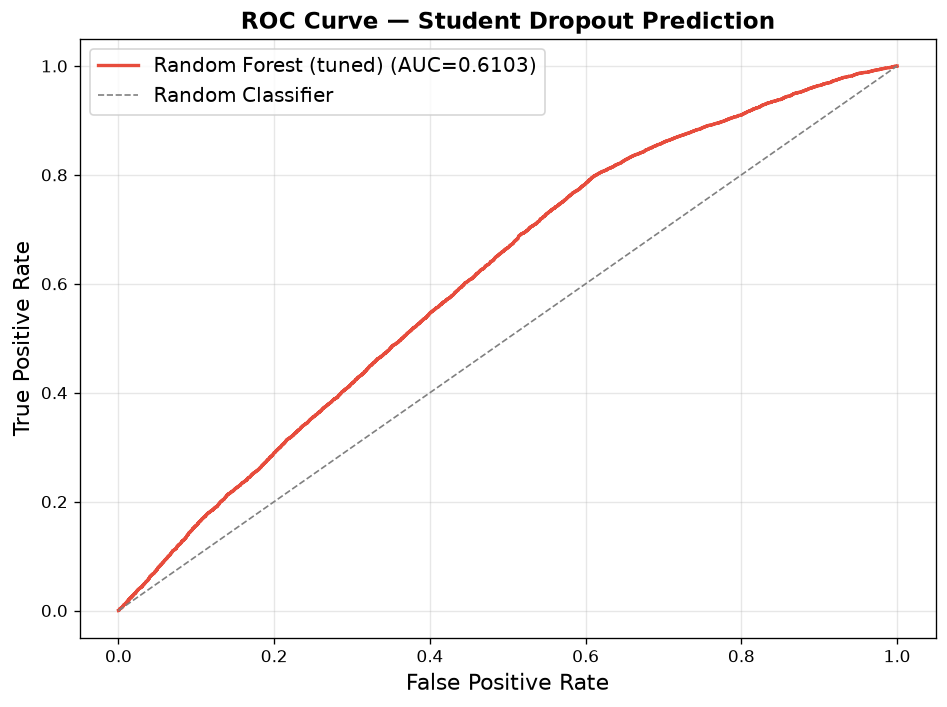

In [3]:
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(fpr, tpr, color='#E74C3C', lw=2, label=f'{model_name} (AUC={auc:.4f})')
ax.plot([0,1],[0,1], 'gray', lw=1, linestyle='--', label='Random Classifier')
ax.set_xlabel('False Positive Rate', fontsize=13)
ax.set_ylabel('True Positive Rate', fontsize=13)
ax.set_title('ROC Curve — Student Dropout Prediction', fontsize=14, fontweight='bold')
ax.legend(fontsize=12); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'roc_curve.png', dpi=150)
plt.show()


## 3.3 Precision-Recall Curve
More informative than ROC for highly imbalanced classes (~8.85% positive).

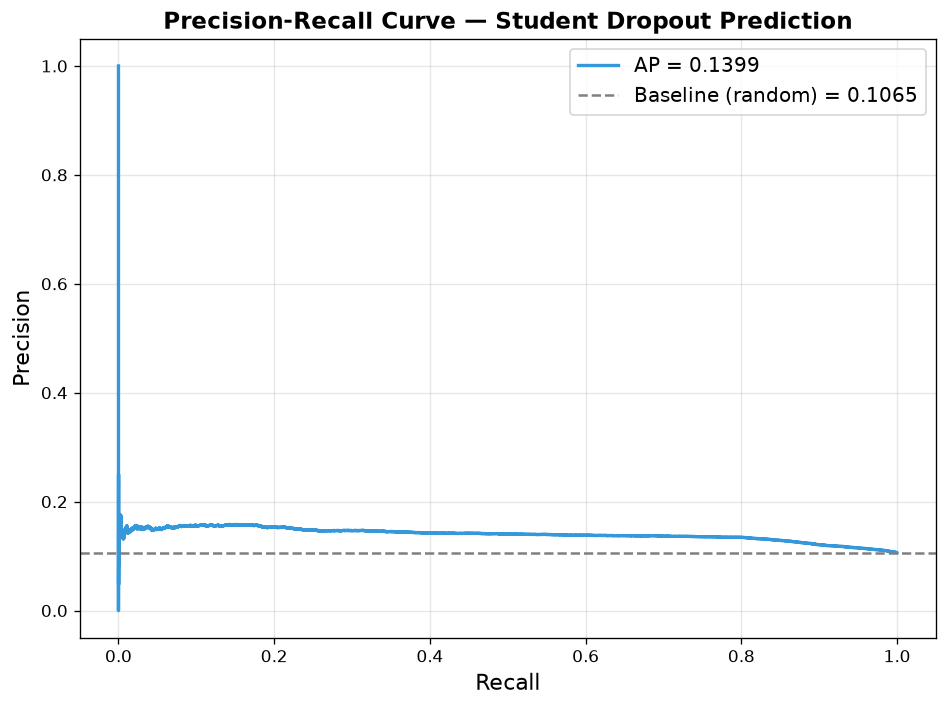

In [4]:
prec, rec, _ = precision_recall_curve(y_test, y_prob)
ap = average_precision_score(y_test, y_prob)

fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rec, prec, color='#3498DB', lw=2, label=f'AP = {ap:.4f}')
ax.axhline(y=y_test.mean(), color='gray', linestyle='--',
           label=f'Baseline (random) = {y_test.mean():.4f}')
ax.set_xlabel('Recall', fontsize=13)
ax.set_ylabel('Precision', fontsize=13)
ax.set_title('Precision-Recall Curve — Student Dropout Prediction',
             fontsize=14, fontweight='bold')
ax.legend(fontsize=12); ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'precision_recall_curve.png', dpi=150)
plt.show()


## 3.4 Confusion Matrix

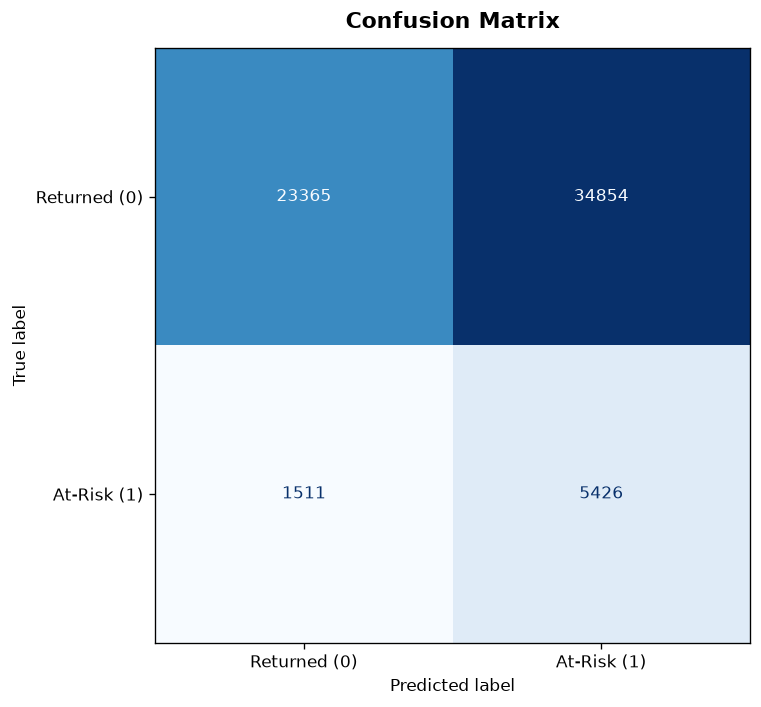

True Negatives (correctly predicted return): 23,365
False Positives (flagged at-risk, actually returned): 34,854
False Negatives (missed dropouts): 1,511
True Positives (correctly flagged at-risk): 5,426


In [5]:
cm = confusion_matrix(y_test, y_pred)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=['Returned (0)', 'At-Risk (1)']).plot(
    ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix', fontsize=13, fontweight='bold', pad=12)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=150)
plt.show()

tn, fp, fn, tp = cm.ravel()
print(f"True Negatives (correctly predicted return): {tn:,}")
print(f"False Positives (flagged at-risk, actually returned): {fp:,}")
print(f"False Negatives (missed dropouts): {fn:,}")
print(f"True Positives (correctly flagged at-risk): {tp:,}")


## 3.5 Feature Importance

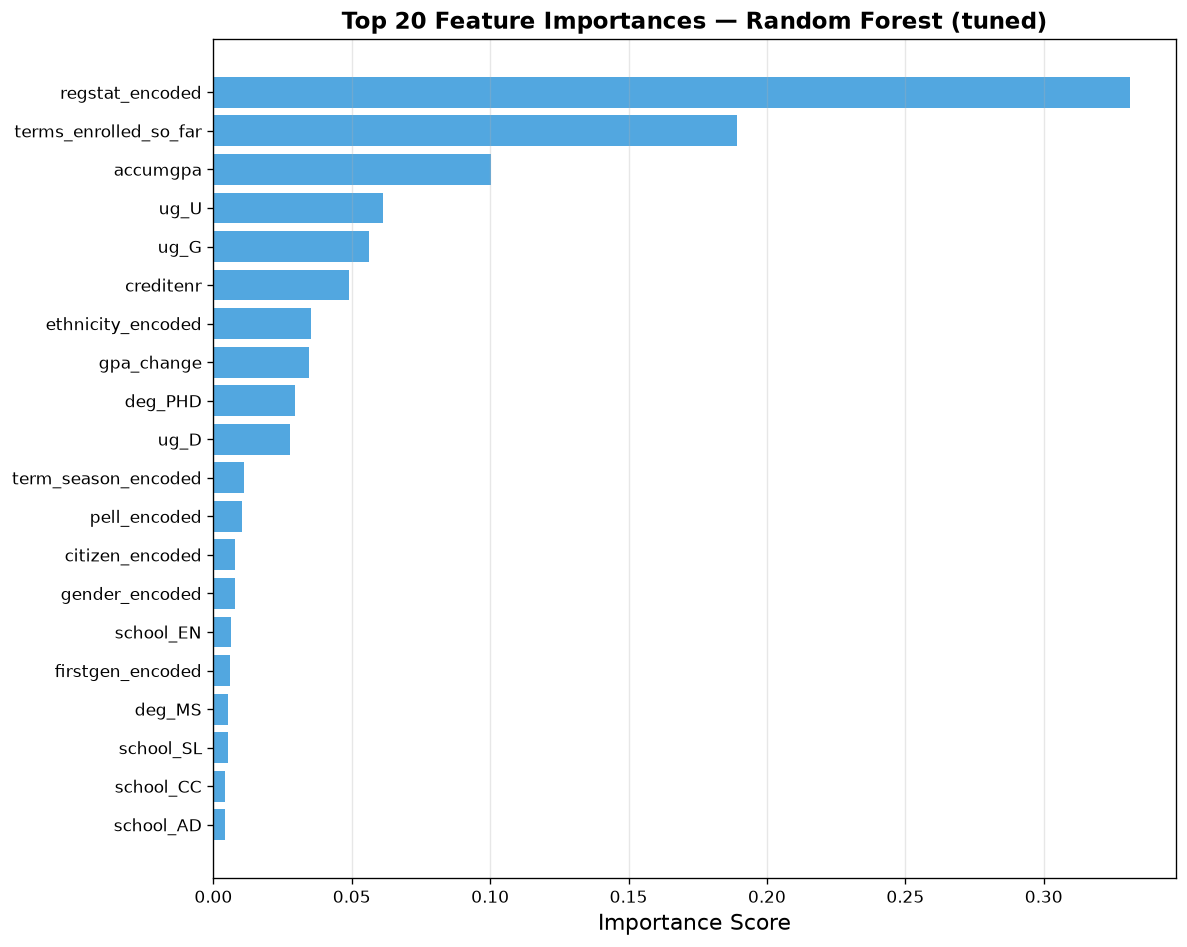

In [6]:
if hasattr(model, 'feature_importances_'):
    importances = model.feature_importances_
elif hasattr(model, 'coef_'):
    importances = np.abs(model.coef_[0])
else:
    print("Feature importance not available for this model type.")
    importances = None

if importances is not None:
    feat_df = pd.DataFrame({'Feature': feat_names, 'Importance': importances})
    feat_df = feat_df.sort_values('Importance', ascending=True).tail(20)

    fig, ax = plt.subplots(figsize=(10, 8))
    ax.barh(feat_df['Feature'], feat_df['Importance'], color='#3498DB', alpha=0.85)
    ax.set_xlabel('Importance Score', fontsize=13)
    ax.set_title(f'Top 20 Feature Importances — {model_name}',
                 fontsize=14, fontweight='bold')
    ax.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'feature_importance.png', dpi=150)
    plt.show()


## 3.6 SHAP Explainability
SHAP (SHapley Additive exPlanations) shows which features pushed each prediction toward at-risk or not.

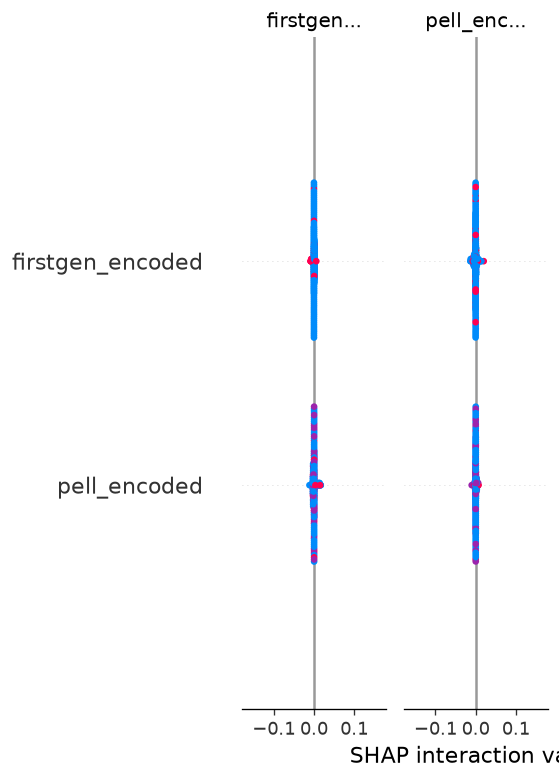

SHAP summary saved.


In [7]:
try:
    import shap
    X_sample = X_test.iloc[:300] if len(X_test) > 300 else X_test
    explainer = shap.TreeExplainer(model)
    shap_vals = explainer.shap_values(X_sample)
    if isinstance(shap_vals, list):
        shap_vals = shap_vals[1]  # class 1 for binary

    shap.summary_plot(shap_vals, X_sample, feature_names=feat_names,
                      show=False, plot_size=(10, 8))
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'shap_summary.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("SHAP summary saved.")
except Exception as e:
    print(f"SHAP skipped: {e}")


## 3.7 Model Comparison Chart

## 3.6b Raw Probability Distribution Diagnostic
Check whether the model produces real signal before picking a threshold.


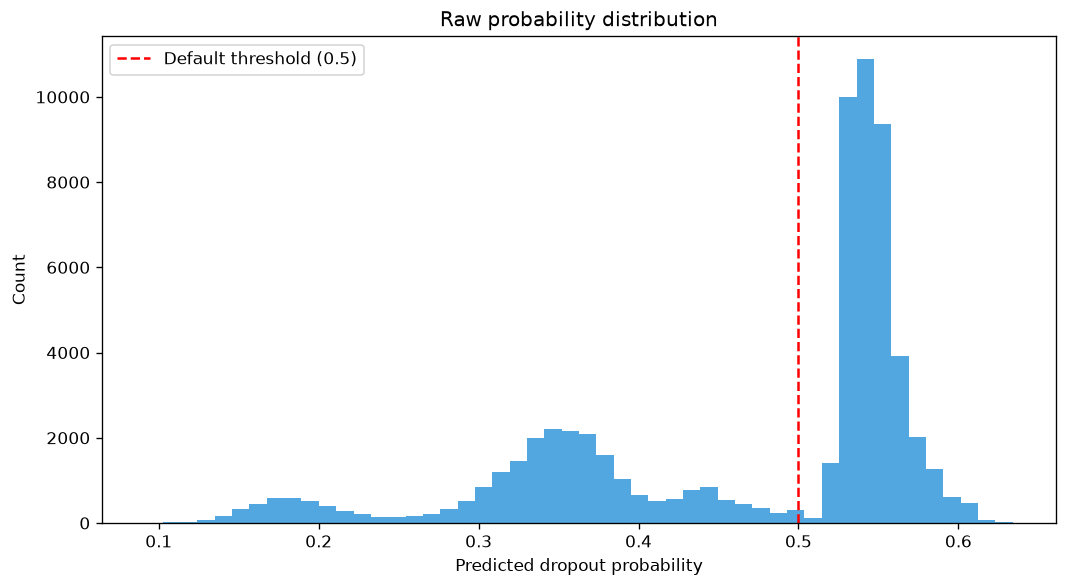

Max probability predicted: 0.6339
Mean probability predicted: 0.4677
% above 0.3: 91.8%
% above 0.2: 95.8%
% above 0.1: 100.0%


In [8]:
plt.figure(figsize=(9, 5))
plt.hist(y_prob, bins=50, color='#3498DB', alpha=0.85)
plt.title('Raw probability distribution')
plt.xlabel('Predicted dropout probability')
plt.ylabel('Count')
plt.axvline(x=0.5, color='red', linestyle='--', label='Default threshold (0.5)')
plt.legend()
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'probability_distribution.png', dpi=150)
plt.show()

print(f'Max probability predicted: {y_prob.max():.4f}')
print(f'Mean probability predicted: {y_prob.mean():.4f}')
print(f'% above 0.3: {(y_prob > 0.3).mean():.1%}')
print(f'% above 0.2: {(y_prob > 0.2).mean():.1%}')
print(f'% above 0.1: {(y_prob > 0.1).mean():.1%}')


## 3.7 Optimal Prediction Threshold
With ~8-9% positive class, a 0.5 threshold almost never predicts at-risk because raw probabilities cluster well below 0.5. Find the threshold that maximises F1 on the test set from the PR curve.

In [9]:
## Optimal Threshold
# With 8-9% at-risk rate, raw probabilities cluster below 0.5.
# A 0.5 threshold will almost never predict at-risk.
# Find the threshold that maximises F1 on the test set.

from sklearn.metrics import precision_recall_curve

prec, rec, thresholds = precision_recall_curve(y_test, y_prob)
f1_scores = 2 * prec * rec / (prec + rec + 1e-8)
optimal_idx = f1_scores.argmax()
optimal_threshold = thresholds[optimal_idx]

print(f'Optimal threshold (max F1): {optimal_threshold:.4f}')
print(f'At this threshold -> Precision={prec[optimal_idx]:.4f} | '
      f'Recall={rec[optimal_idx]:.4f} | F1={f1_scores[optimal_idx]:.4f}')

# Apply optimal threshold
y_pred_opt = (y_prob >= optimal_threshold).astype(int)
print(f'\nClassification report at optimal threshold ({optimal_threshold:.4f}):')
print(classification_report(y_test, y_pred_opt,
      target_names=['Returned (0)', 'At-Risk (1)']))

# Save for use in 04_predict.ipynb
joblib.dump(optimal_threshold, OUTPUT_DIR / 'optimal_threshold.pkl')
print('Saved: optimal_threshold.pkl')


Optimal threshold (max F1): 0.4708
At this threshold -> Precision=0.1347 | Recall=0.7976 | F1=0.2305

Classification report at optimal threshold (0.4708):
              precision    recall  f1-score   support

Returned (0)       0.94      0.39      0.55     58219
 At-Risk (1)       0.13      0.80      0.23      6937

    accuracy                           0.43     65156
   macro avg       0.54      0.59      0.39     65156
weighted avg       0.86      0.43      0.52     65156

Saved: optimal_threshold.pkl


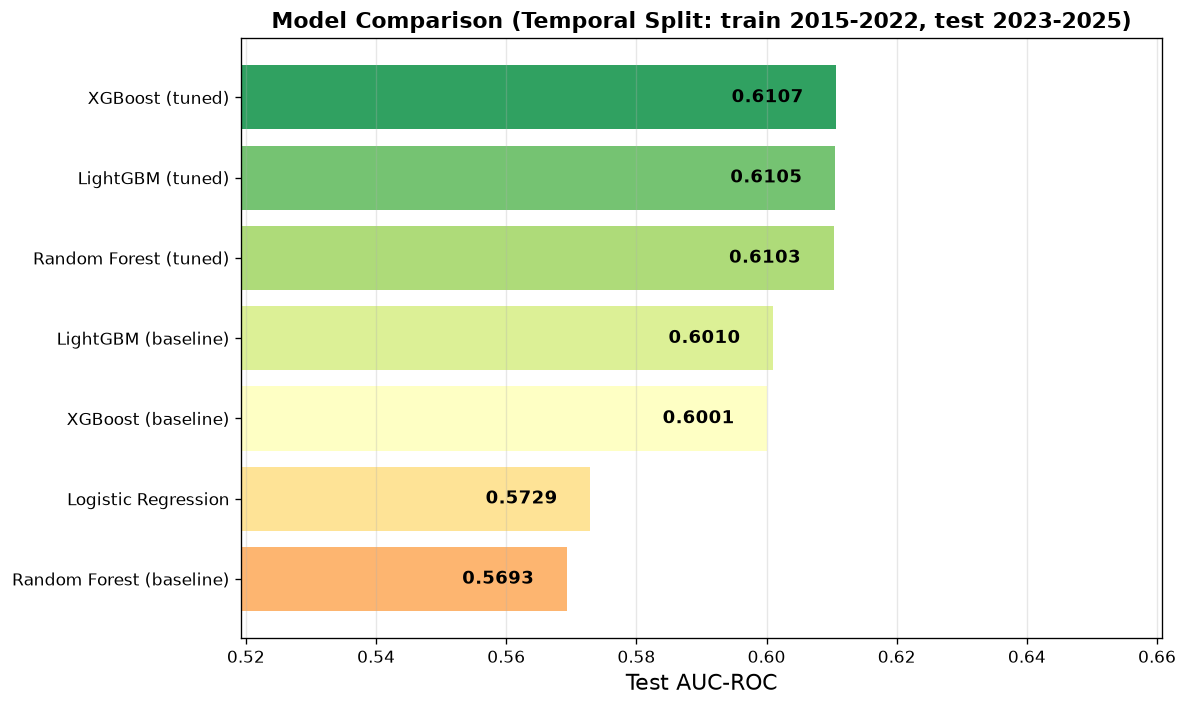

All evaluation plots saved to outputs/


In [10]:
comp = pd.read_csv(OUTPUT_DIR / 'model_comparison.csv').sort_values('Test AUC', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(comp)))
bars = ax.barh(comp['Model'], comp['Test AUC'], color=colors, alpha=0.9)
for bar, val in zip(bars, comp['Test AUC']):
    ax.text(bar.get_width() - 0.005, bar.get_y() + bar.get_height()/2,
            f'{val:.4f}', va='center', ha='right', color='black',
            fontweight='bold', fontsize=11)
ax.set_xlabel('Test AUC-ROC', fontsize=13)
ax.set_title('Model Comparison (Temporal Split: train 2015-2022, test 2023-2025)',
             fontsize=13, fontweight='bold')
ax.set_xlim(max(0.45, comp['Test AUC'].min() - 0.05), min(1.0, comp['Test AUC'].max() + 0.05))
ax.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'model_comparison.png', dpi=150)
plt.show()
print("All evaluation plots saved to outputs/")
